$$\require{mhchem}$$

# ND CBE 60546, Advanced Chemical Reaction Engineering, Fall 2025
## Homework 1
## Due September 3, 2025
Start by sketching out problem and solution approach on paper. If you can solve the problem by hand, do so *neatly*, and either scan your solution and embed the image in your noteback or type the solution into the cell. Otherwise, create python code to solve the problem. Name your variables using meaningful names and liberally comment the solution. Use pyplot or similar package for all plots.


# All in balance
## Q1. One way under consideration for removing harmful "$\ce{NO_x}$" (NO + $\ce{NO2}$) from flue gas is the thermal deNOx process, in which $\ce{NH3}$ is used to reduce the NO to $\ce{N2}$:

$\ce{NO(g) + NH3(g) + O2(g)  -> N2(g) + H2O(g)}$

## The research lab has several gas tanks available to study this reaction, including one containing 2.0% NO in $\ce{N2}$. You can assume all gases behave ideally.

### Q1.1. A number of atoms are changing oxidation state in the thermal deNOx reaction. Specify the oxidation states of each atom in each moleculue.

reactants:

NO: N=+2, O=-2

NH<sub>3</sub>: N=-3, H=+1

O<sub>2</sub>: O=0

products:

N<sub>2</sub>: N=0

H<sub>2</sub>O: O=-2, H=+1



### Q1.2. What type of reaction is this?

Redox reaction

Reduction: Nitrogen in NO goes from +2 to 0, gaining electrons.

Oxidation: Nitrogen in NH3 goes from -3 to 0, loosing lectrons.

Reducting agent is NH3, whereas oxiation agent is NO

### Q1.3. Balance the thermal deNOx reaction, assuming each NH<sub>3</sub> titrates one NO.

$\ce{4NO(g) + 4NH3(g) + O2(g)  -> 4N2(g) + 6H2O(g)}$


### Q1.4. What mass flow rates are necessary to create a stoichiometric mixture at 1 bar total pressure, $400^\circ$C, and 10 liter/s total volumetric flow rate?

In [2]:
# Ideal Gas Law: PV=nRT
R = .0831451 #L bar K-1 mol-1
P = 1 #bar
V = 10 #L/s
T = 673 #K
n = round((P*V)/(R*T),2) #moles/s
print('Total Molar Flow Rate =',n,'moles/s')

Total Molar Flow Rate = 0.18 moles/s


In [3]:
# Calculate molar flow rates for NO, O2, and NH3
# Flow 1, F1: NO from tank containing 2% of NO in N2 (0.02)
# Flow 2, F2: O2 from air flow (0.2)
# Flow 3, F3: Pure NH3 (1)
# Need to solve three equation to get the stocihiometric mixture
# F1*0.02 + F2*0 + F3*0 = 4 -> F1 = 200
# F1*0 + F2*0.2 + F3*0 = 1  -> F2 = 5
# F1*0 + F2*0 + F3*1 = 4    -> F3 = 4
# Total: F1+F2+F3 = 209
# ratios of flow rates:
# F1 = 200/209
# F2 = 5/209
# F3 = 4/209

In [6]:
# Total molar flow rate * ratio = individual molar flow rates
mol_F1 = n*200/209
mol_F2 = n*5/209
mol_F3 = n*4/209
print('Molar Flow Rate of Flow 1 =',round(mol_F1,4),'mol/s')
print('Molar Flow Rate of Flow 2 =',round(mol_F2,4),'mol/s')
print('Molar Flow Rate of Flow 3 =',round(mol_F3,4),'mol/s')
# Molar flow rate * avg MW of flow = individual mass flow rates
MW_F1 = 0.02*30.01 + 0.98*28.134 #[=]g/mol
MW_F2 = 0.2*15.999*2 + 0.8*28.0134
MW_F3 = 1*17.031
mass_F1 = mol_F1*MW_F1
mass_F2 = mol_F2*5/209*MW_F2
mass_F3 = mol_F3*4/209*MW_F3
print('Mass Flow Rate of Flow 1 =',round(mass_F1,2),'g/s')
print('Mass Flow Rate of Flow 2 =',round(mass_F2,2),'g/s')
print('Mass Flow Rate of Flow 3 =',round(mass_F3,2),'g/s')


Molar Flow Rate of Flow 1 = 0.1722 mol/s
Molar Flow Rate of Flow 2 = 0.0043 mol/s
Molar Flow Rate of Flow 3 = 0.0034 mol/s
Mass Flow Rate of Flow 1 = 4.85 g/s
Mass Flow Rate of Flow 2 = 0.0 g/s
Mass Flow Rate of Flow 3 = 0.0 g/s


### Q1.5. Plot the molar flow rates of all five gases as a function of reaction advancement.

Text(0.5, 1.0, 'Molar Flow Rates vs Reaction Advancement')

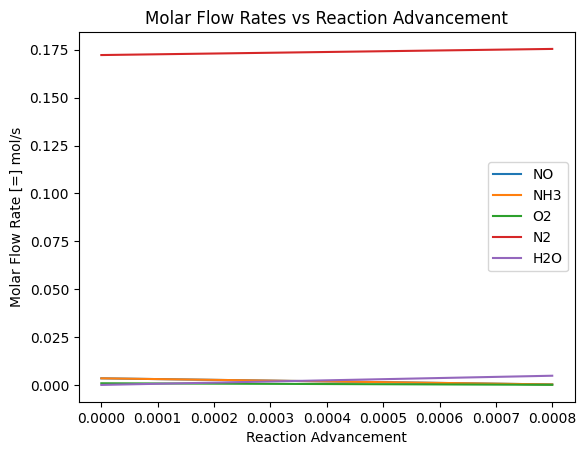

In [10]:
import numpy as np
import matplotlib.pyplot as plt

adv = np.arange(0, 1, 0.0001)
NO = mol_F1*0.02-4*adv
O2 = mol_F2*0.2-adv
NH3 = mol_F3-4*adv
N2 = 4*adv+mol_F1*0.98+mol_F2*0.8
H2O = 6*adv

# need to find an index when the limiting agent goes 0
# the limiting agent is O2
# find an index that the limiting agent is all consumed
end = np.where(O2<0)[0][0]

plt.plot(adv[:end],NO[:end],label = 'NO')
plt.plot(adv[:end],NH3[:end],label = 'NH3')
plt.plot(adv[:end],O2[:end],label = 'O2')
plt.plot(adv[:end],N2[:end],label = 'N2')
plt.plot(adv[:end],H2O[:end],label = 'H2O')
plt.legend()
plt.xlabel('Reaction Advancement')
plt.ylabel('Molar Flow Rate [=] mol/s')
plt.title('Molar Flow Rates vs Reaction Advancement')

### Q1.6. Plot the total volumetric flow rate as a function of reaction advancement.

Text(0.5, 1.0, 'Total Volumetric Flow Rate vs Reaction Advancement')

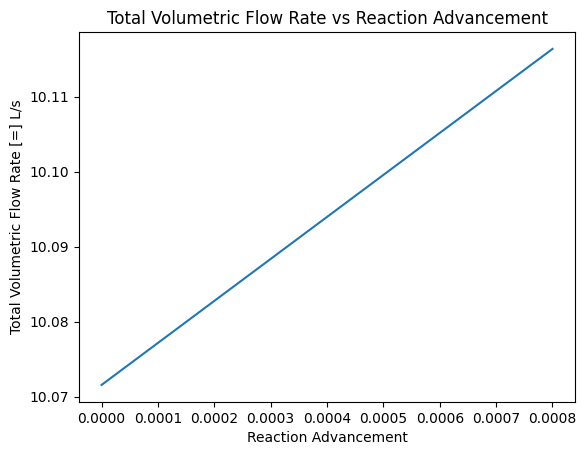

In [11]:
# Ideal Gas Law: PV=nRT
# V = nRT/P
Tot = (NO+NH3+O2+N2+H2O)*10**-3*8.314*10**3*673/10**5*10**3
plt.plot(adv[:end],Tot[:end])
plt.xlabel('Reaction Advancement')
plt.ylabel('Total Volumetric Flow Rate [=] L/s')
plt.title('Total Volumetric Flow Rate vs Reaction Advancement')

# Q2. NH<sub>3</sub> oxidation is an undesirable side-reaction of thermal deNOx:

$\ce{NH3(g) + O2(g) -> NO(g) + H2O(g)}$

### Q2.1. Balance the $\ce{NH3}$ oxidation reaction.

$\ce{4NH3(g) + 5O2(g) -> 4NO(g) + 6H2O(g)}$

### Q2.2. Under the stoichiometric conditions described above, the reactor generates 0.036 g/s NO and 0.017 g/s $\ce{N2}$. How effectively is the $\ce{NH3}$ being used for thermal deNOx? (*Hint:* What are the advancements of the two reactions?)

Desired: $\ce{4NO(g) + 4NH3(g) + O2(g)  -> 4N2(g) + 6H2O(g)}$

Undesired:$\ce{4NH3(g) + 5O2(g) -> 4NO(g) + 6H2O(g)}$

In [12]:
xi1 = 0.017/28.134 #[=] mol/s
xi2 = 0.036/30.01
print(f'{xi1:.2E}')
print(f'{xi2:.2E}')
X = xi1/(xi1+xi2)
print(f'{round(X,3)*100}% of NH3 is effectively being used in desired reaction, deNOx')

6.04E-04
1.20E-03
33.5% of NH3 is effectively being used in desired reaction, deNOx
